In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad
import torch

from copy import deepcopy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../../")

In [3]:
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
from mbt_gym.agents.BaselineAgents import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *

# helpers
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.index_names import *
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.wrappers import *

### Parameters

In [13]:
seed = 42

initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
max_inventory=100
fads_proportion = 0 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
phi = 30
psi = 0
k = 1
gamma = 1
alpha=0.001
mu=0
big_phi = 0.1

risk_aversion = 0.1
num_trajectories=1000


In [14]:
all_results = []
env_names = [
    "BM + Poisson + AS",
    "ABM w/Fads + Poisson + AS",
    "ABM w/Fads + Modified Poisson + AS",
    "ABM w/Fads + Modified Poisson + Full Info",
    "ABM w/Fads + Modified Poisson + Partial Info"
]



## Enviroment A: 
- Brownian Motion Mid Price
- Poisson Arrival
- Avellaneda Stoikov agent

In [15]:
def get_as_env(num_trajectories:int = 1):
    midprice_model = BrownianMotionMidpriceModel(initial_price = initial_price, 
                                                 volatility=sigma, step_size=1/n_steps,
                                                 terminal_time = terminal_time,
                                                 num_trajectories=num_trajectories)
    arrival_rate=psi+phi
    arrival_model = PoissonArrivalModel(intensity=np.array([arrival_rate, arrival_rate]), 
                                        step_size=1/n_steps, 
                                        num_trajectories=num_trajectories)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=1/n_steps,
                                                     num_trajectories=num_trajectories)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [16]:
as_env = get_as_env()
as_agent = ModifiedAvellanedaStoikovAgent(risk_aversion=risk_aversion, env=as_env)

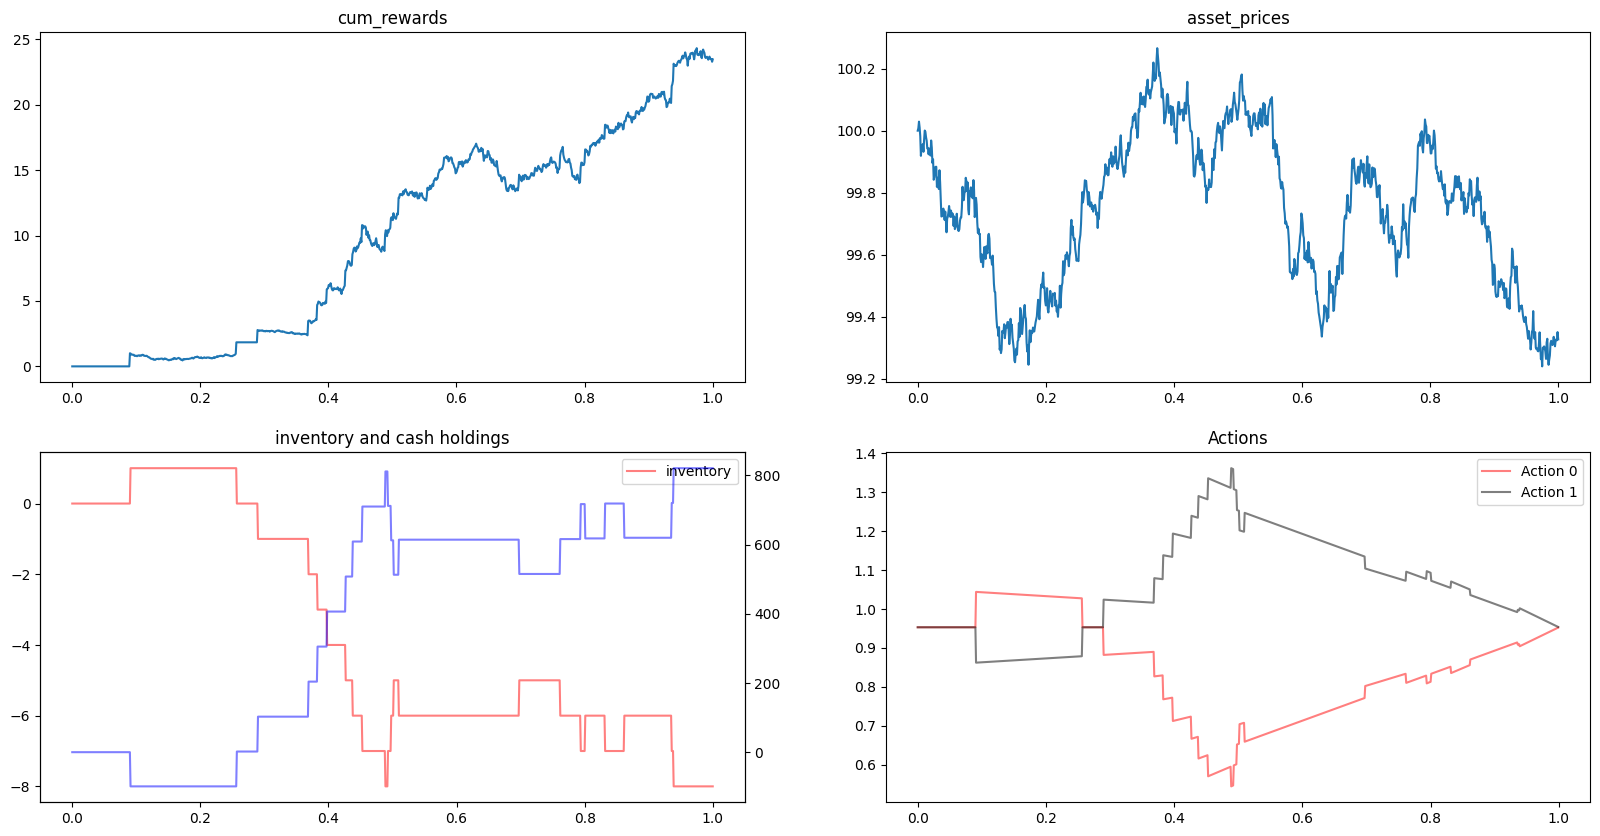

In [17]:
plot_trajectory(as_env, as_agent, seed = seed)

In [18]:
vec_env = get_as_env(num_trajectories)
vec_as = ModifiedAvellanedaStoikovAgent(risk_aversion=risk_aversion, env=vec_env)

In [19]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [20]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [21]:
all_results.append(results)
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,1.906204,21.180193,4.900773,-0.106,3.520052


## Enviroment B: 
- Arithmetic Brownian Motion with Fads Mid Price
- Poisson Arrival
- Avellaneda Stoikov agent

In [22]:
def get_as_env(num_trajectories:int = 1):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_rate=psi+phi
    arrival_model = PoissonArrivalModel(intensity=np.array([arrival_rate, arrival_rate]), 
                                        step_size=1/n_steps, 
                                        num_trajectories=num_trajectories)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=1/n_steps,
                                                     num_trajectories=num_trajectories)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [23]:
as_env = get_as_env()

In [24]:
as_agent = ModifiedAvellanedaStoikovAgent(risk_aversion=risk_aversion, env=as_env)
print(as_env.model_dynamics
      .midprice_model)


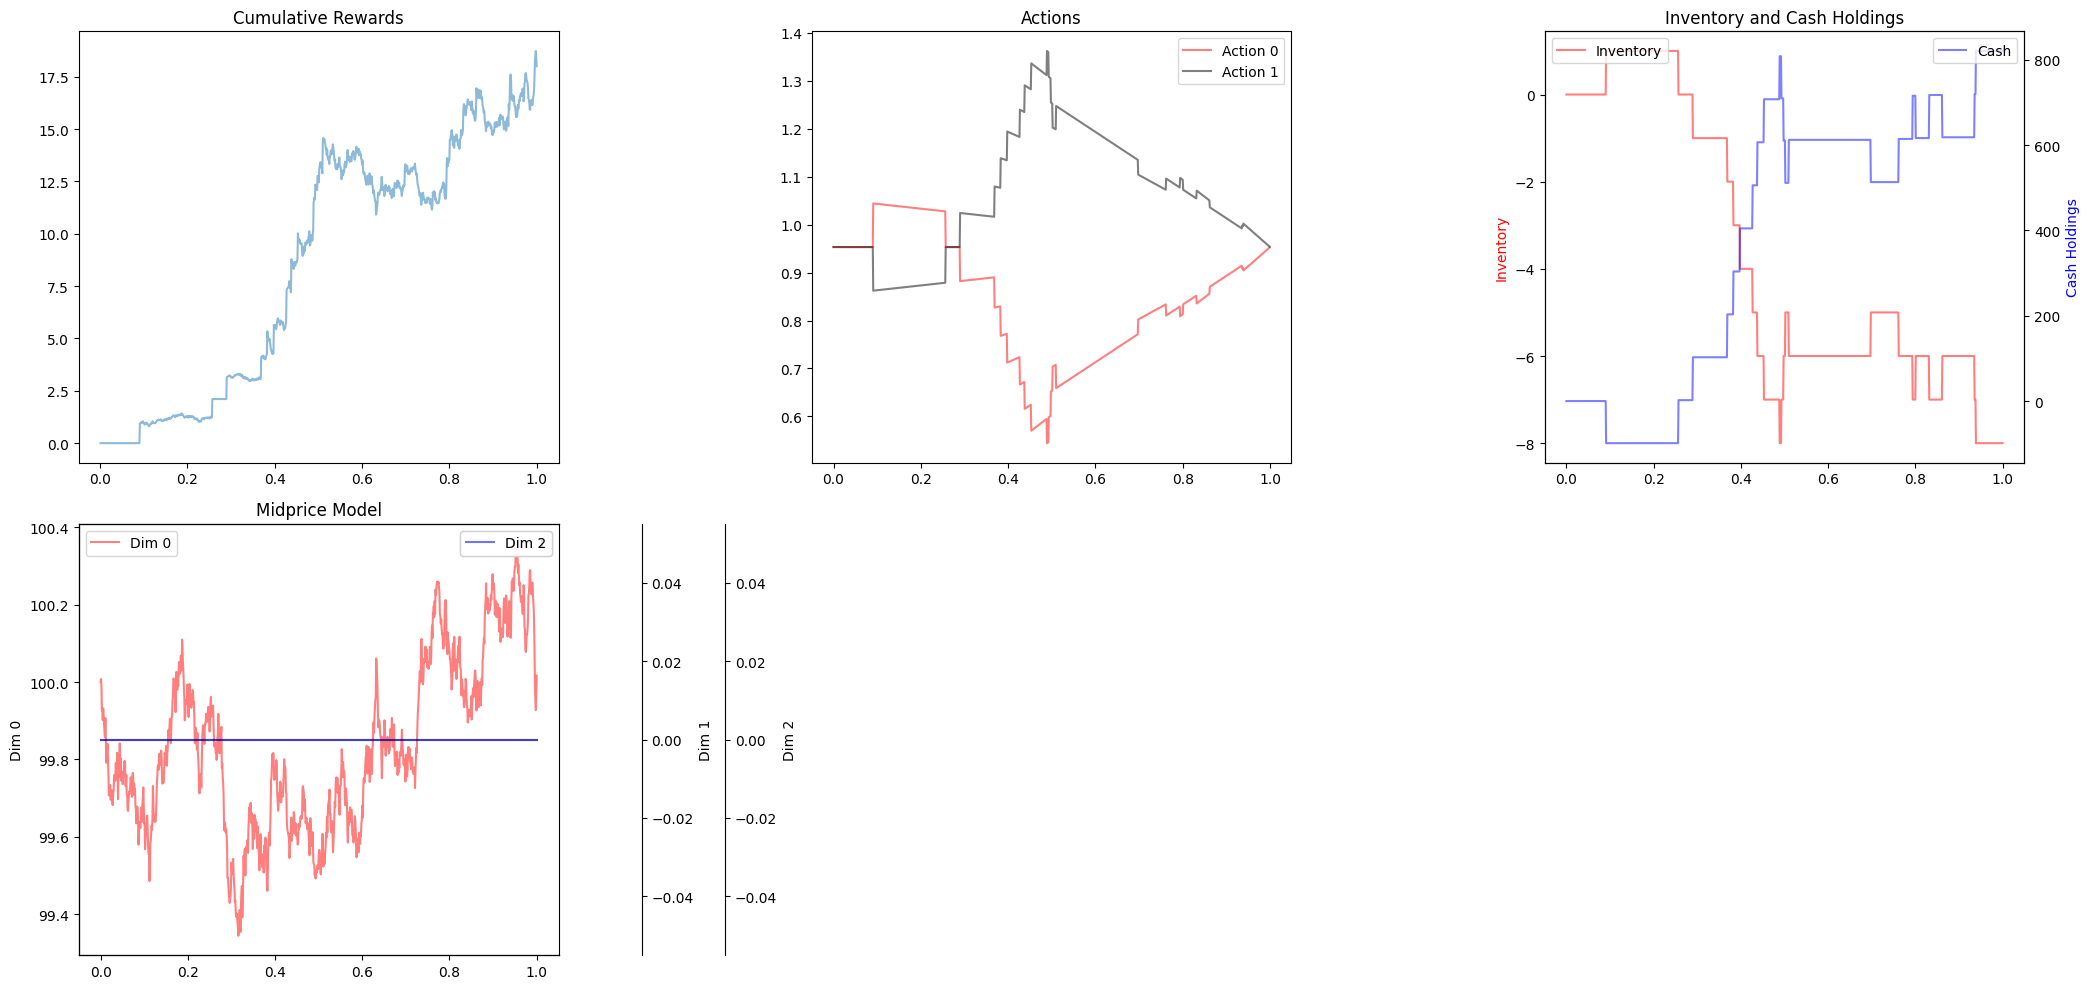

In [25]:
plot_trajectory_extended(as_env, as_agent)

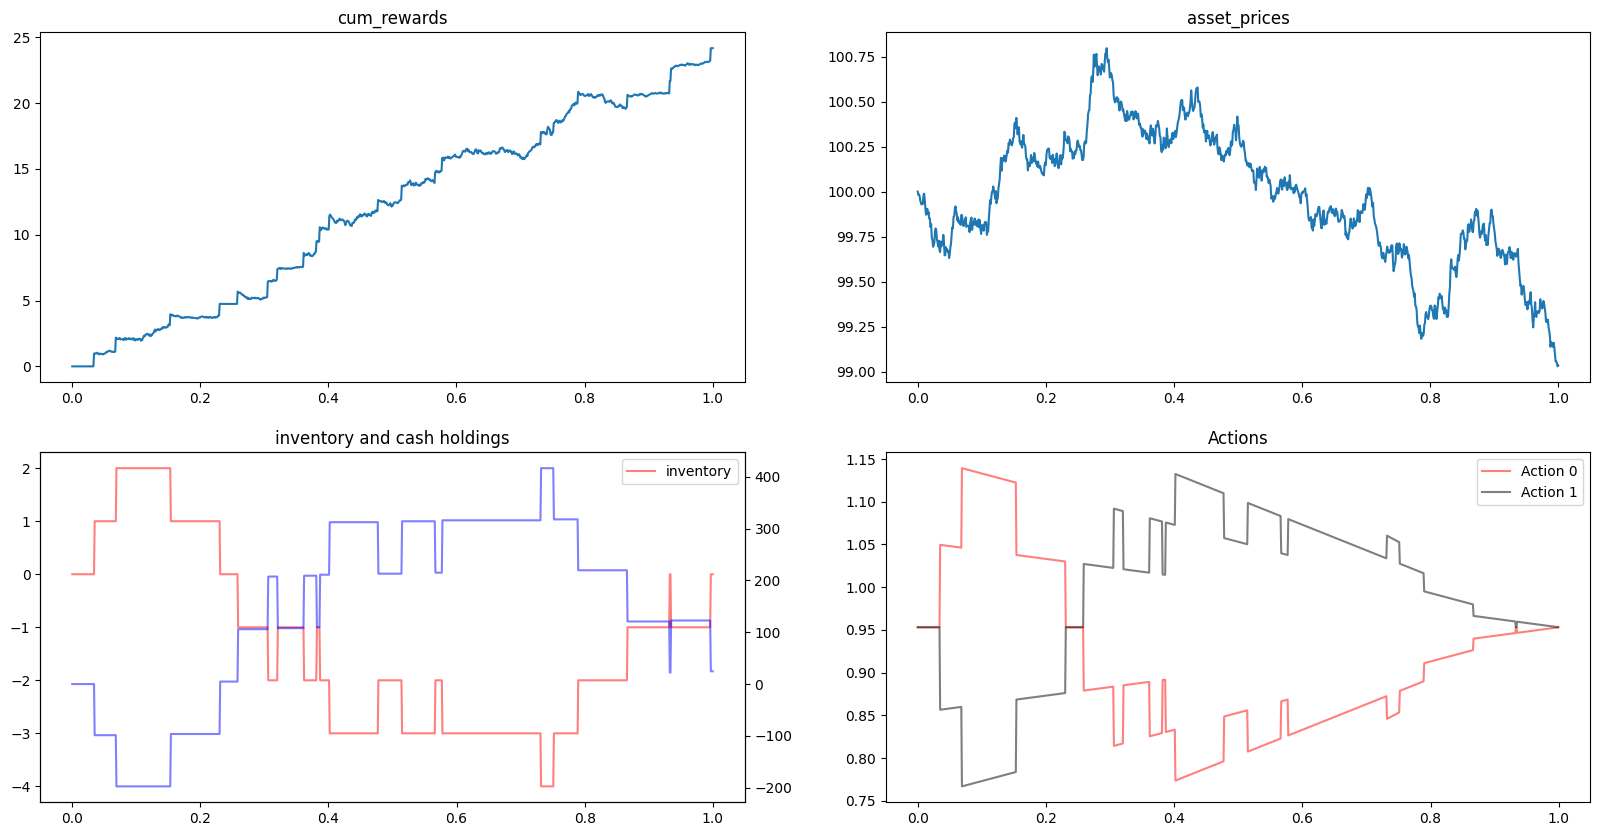

In [26]:
plot_trajectory(as_env, as_agent, seed = 50)

In [27]:
vec_env = get_as_env(num_trajectories)
vec_as = ModifiedAvellanedaStoikovAgent(risk_aversion=risk_aversion, env=vec_env)

In [28]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [29]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [30]:
all_results.append(results)
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,1.906204,21.335384,4.956853,-0.106,3.520052


## Enviroment C: 
- Arithmetic Brownian Motion with Fads Mid Price
- Modified Poisson Arrival
- Avellaneda Stoikov agent

In [31]:
from mbt_gym.stochastic_processes.midprice_models import ArithmeticBrownianMotionWithFadsMidpriceModel

In [34]:
def get_as_env(num_trajectories:int = 1,):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [35]:
as_env = get_as_env()

In [36]:
as_agent = ModifiedAvellanedaStoikovAgent(risk_aversion=risk_aversion, env=as_env)
print(as_env.model_dynamics
      .midprice_model)


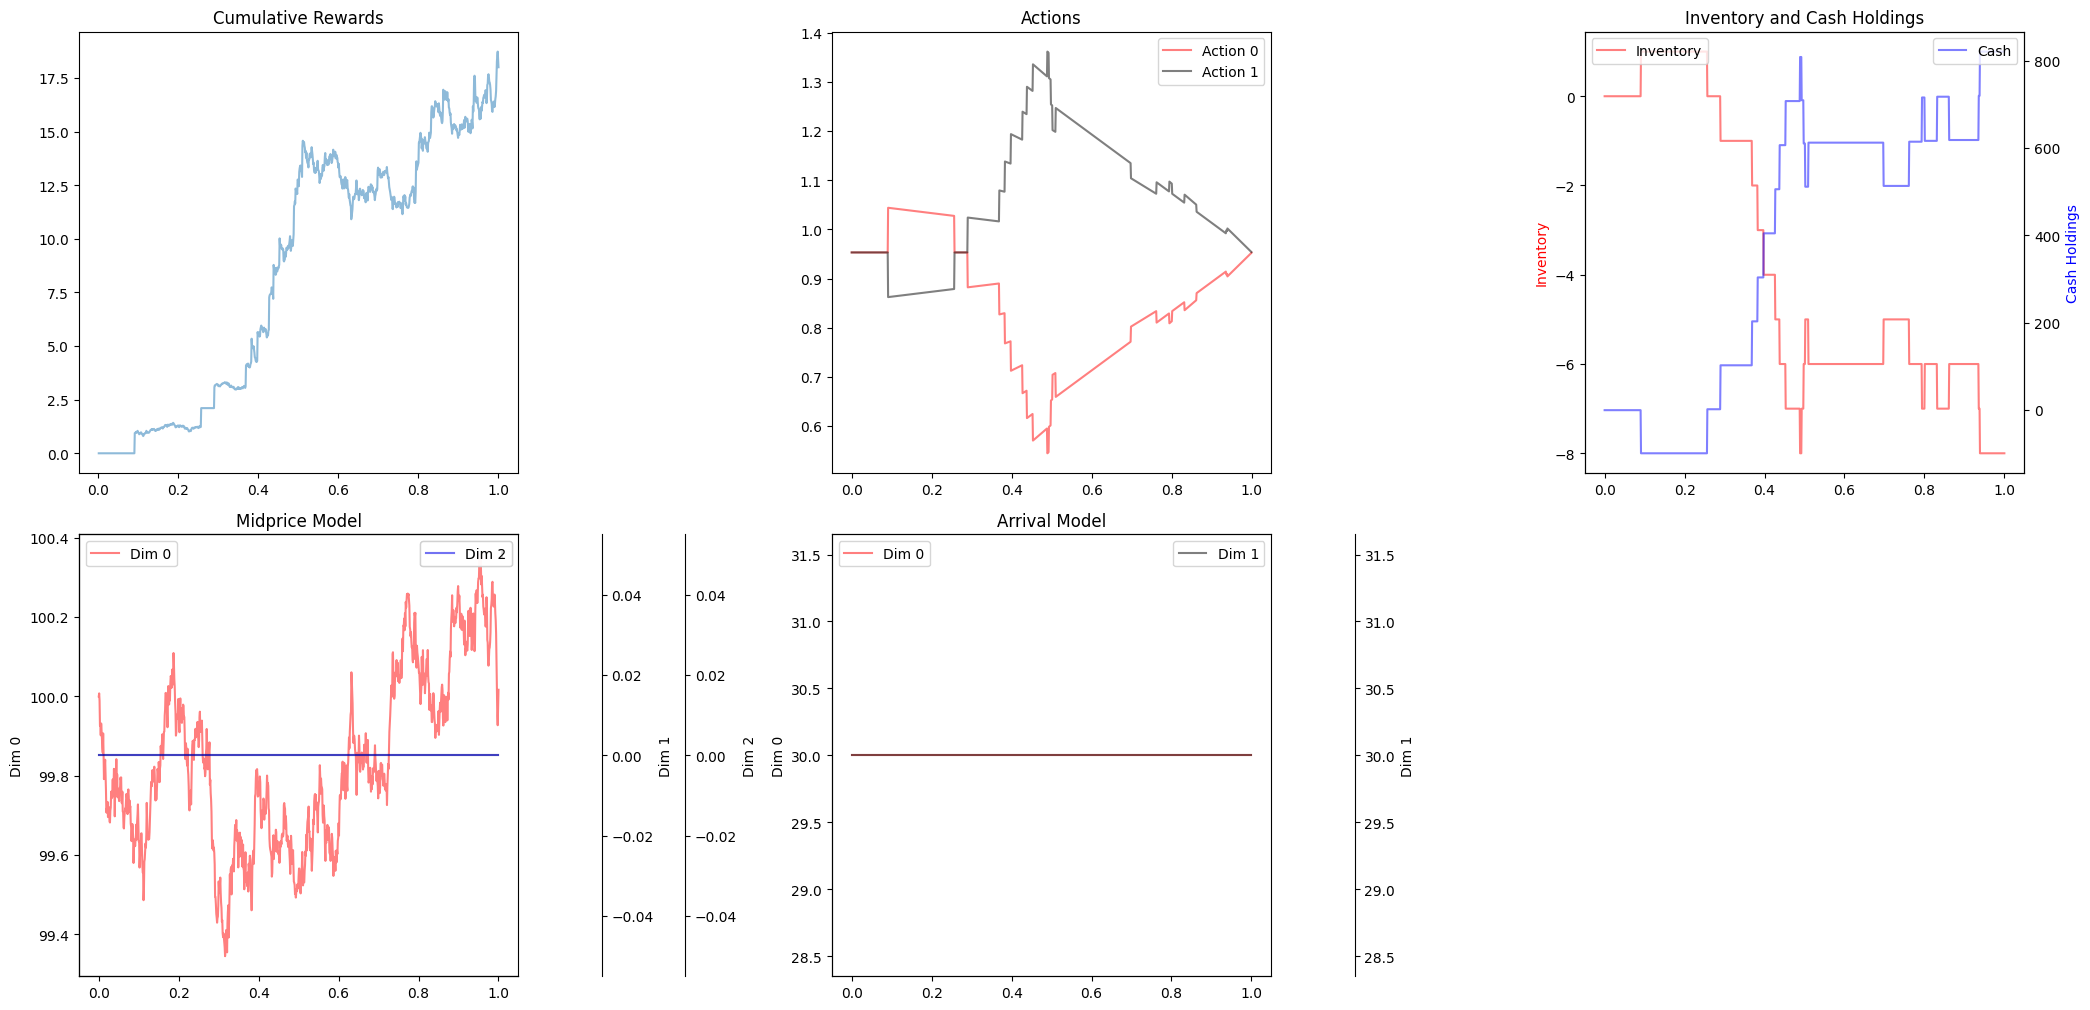

In [37]:
plot_trajectory_extended(as_env, as_agent)

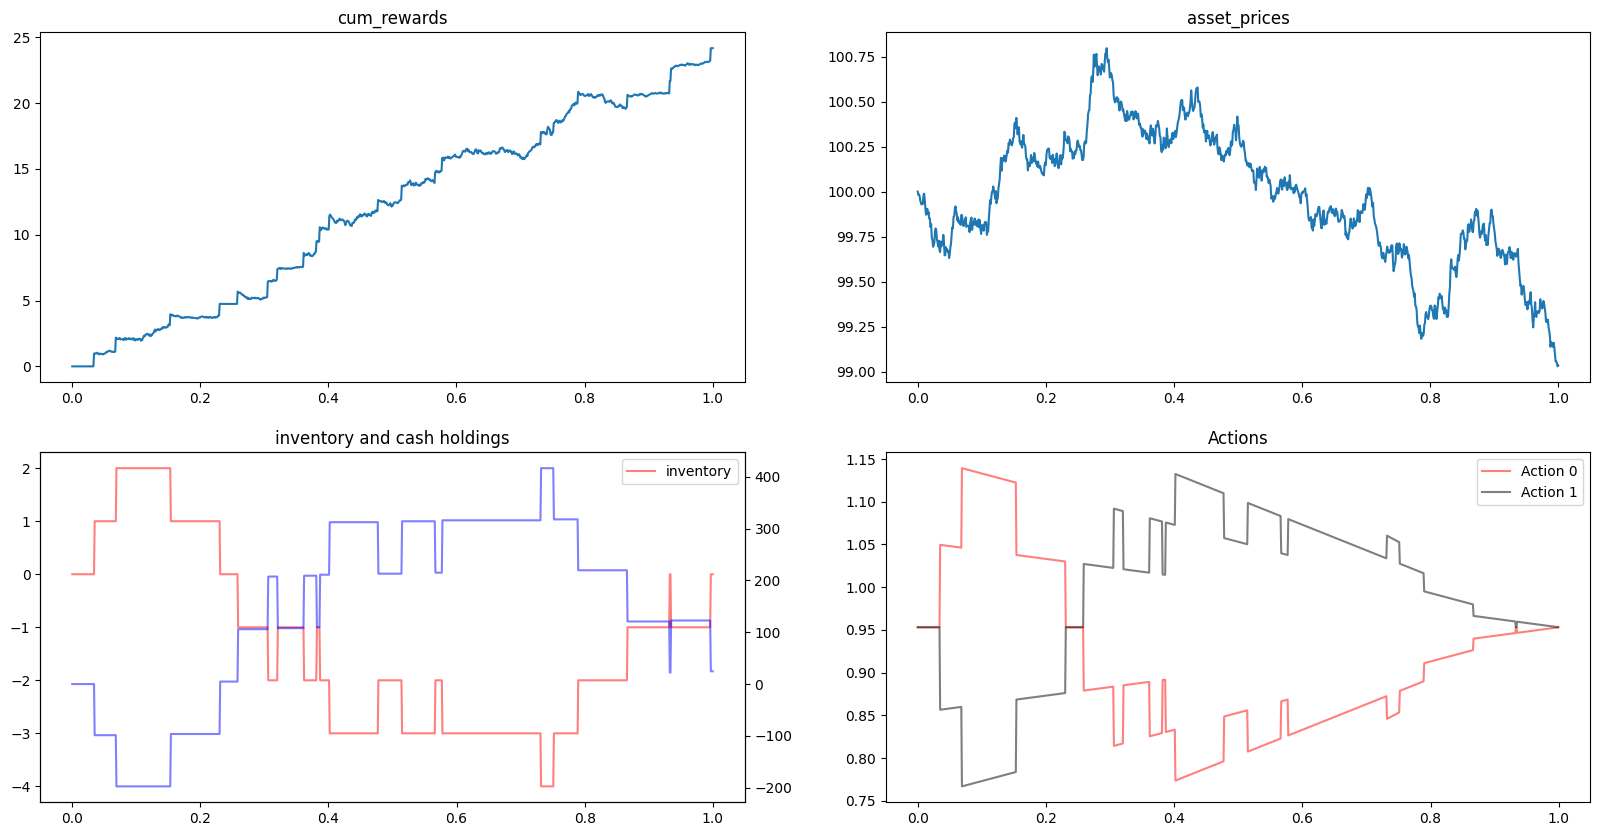

In [38]:
plot_trajectory(as_env, as_agent, seed = 50)

In [39]:
vec_env = get_as_env(num_trajectories)
vec_as = ModifiedAvellanedaStoikovAgent(risk_aversion=risk_aversion, env=vec_env)

In [40]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [41]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [42]:
all_results.append(results)
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,1.906204,21.335384,4.956853,-0.106,3.520052


## Enviroment D: 
- Arithmetic Brownian Motion with Fads Mid Price
- Poisson Arrival
- Optimized Full Information agent

In [45]:
def get_as_env(num_trajectories:int = 1,):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [46]:
as_env = get_as_env()

In [47]:
as_agent = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=as_env)
print(as_env.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


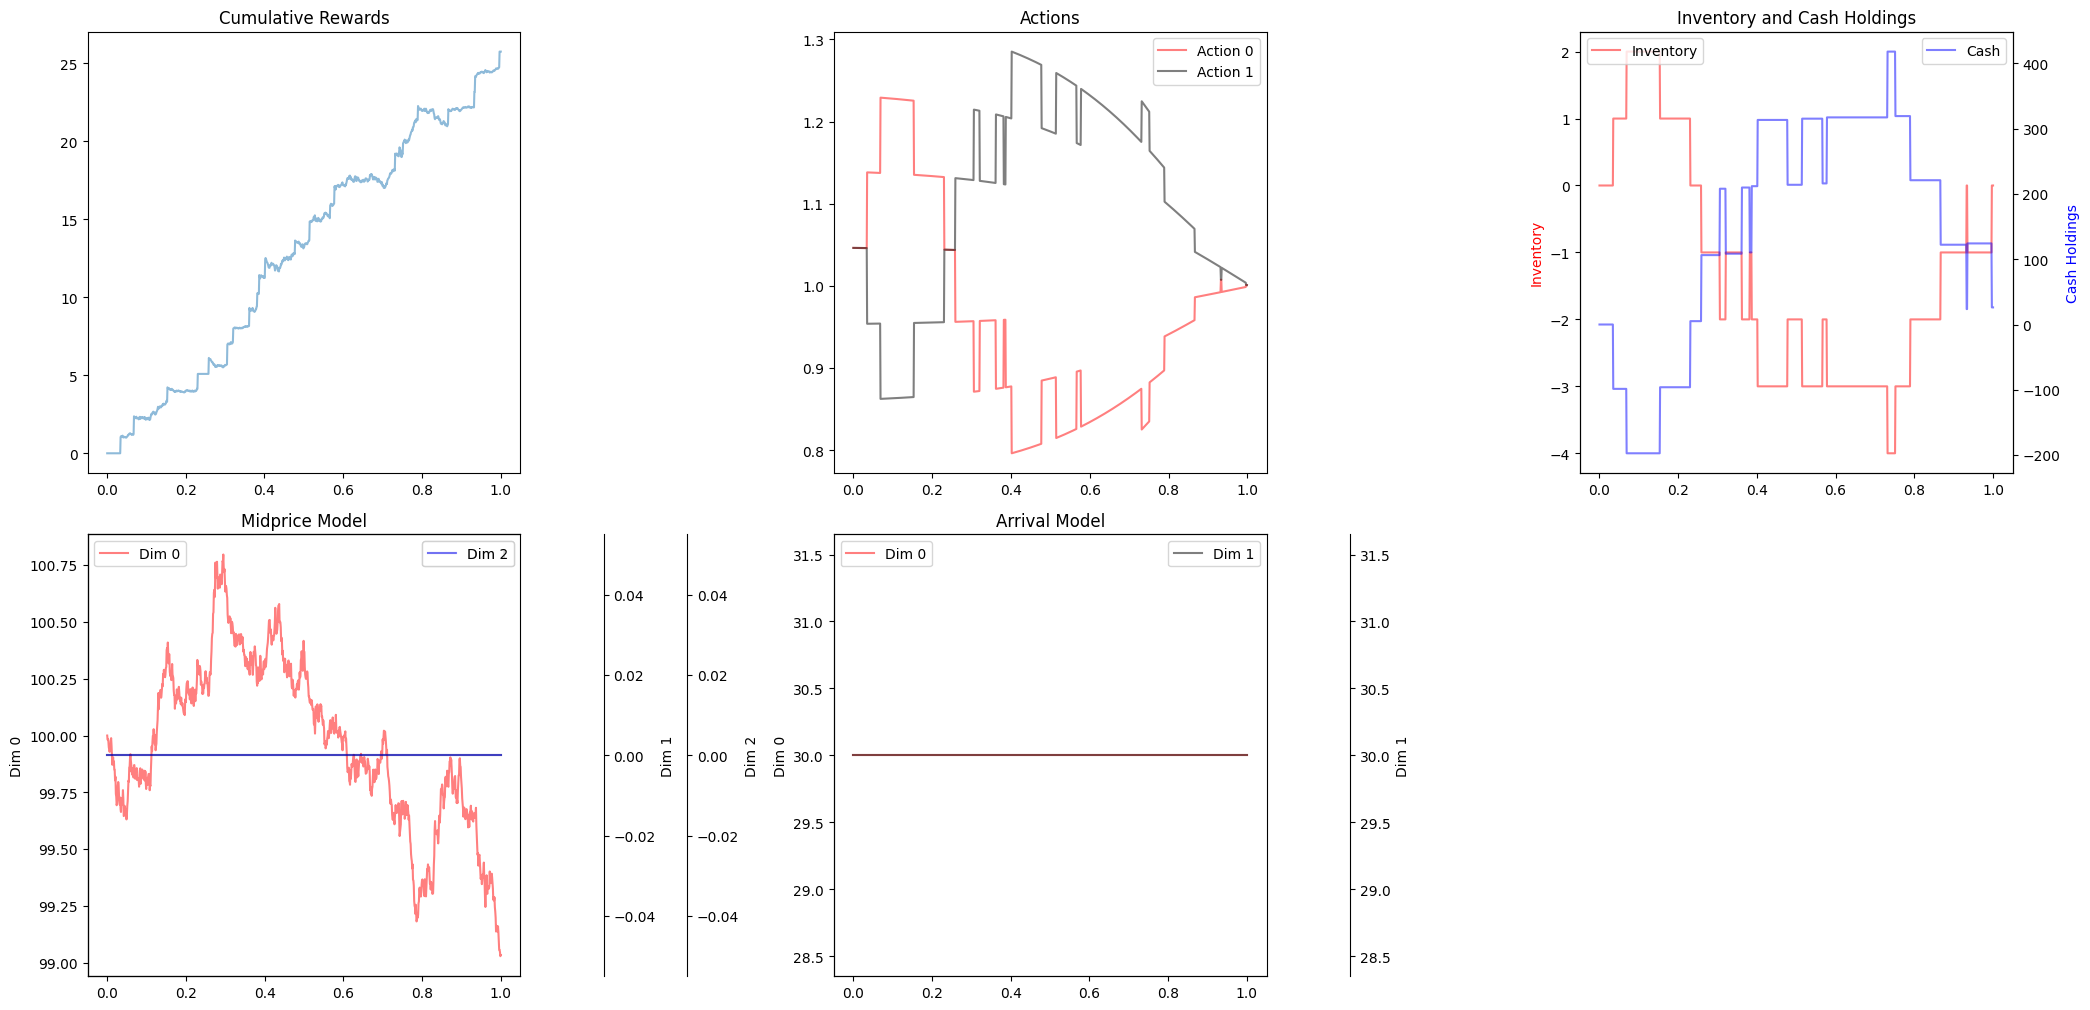

In [48]:
plot_trajectory_extended(as_env, as_agent, seed = 50)

In [49]:
vec_env = get_as_env(num_trajectories)
vec_as = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)


✓ Pre-computed ODE solutions for 1000 time points


In [50]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [51]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [52]:
all_results.append(results)
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065352,21.34272,4.96101,-0.08,3.069462


## Enviroment E: 
- Arithmetic Brownian Motion with Fads Mid Price
- Poisson Arrival
- Optimized Partial Information agent

In [55]:
def get_as_env(num_trajectories:int = 1,):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=max_inventory,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [56]:
as_env = get_as_env()

In [57]:
as_agent = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=as_env)
print(as_env.model_dynamics
      .midprice_model)

✓ Pre-computed ODE solutions for 1000 time points


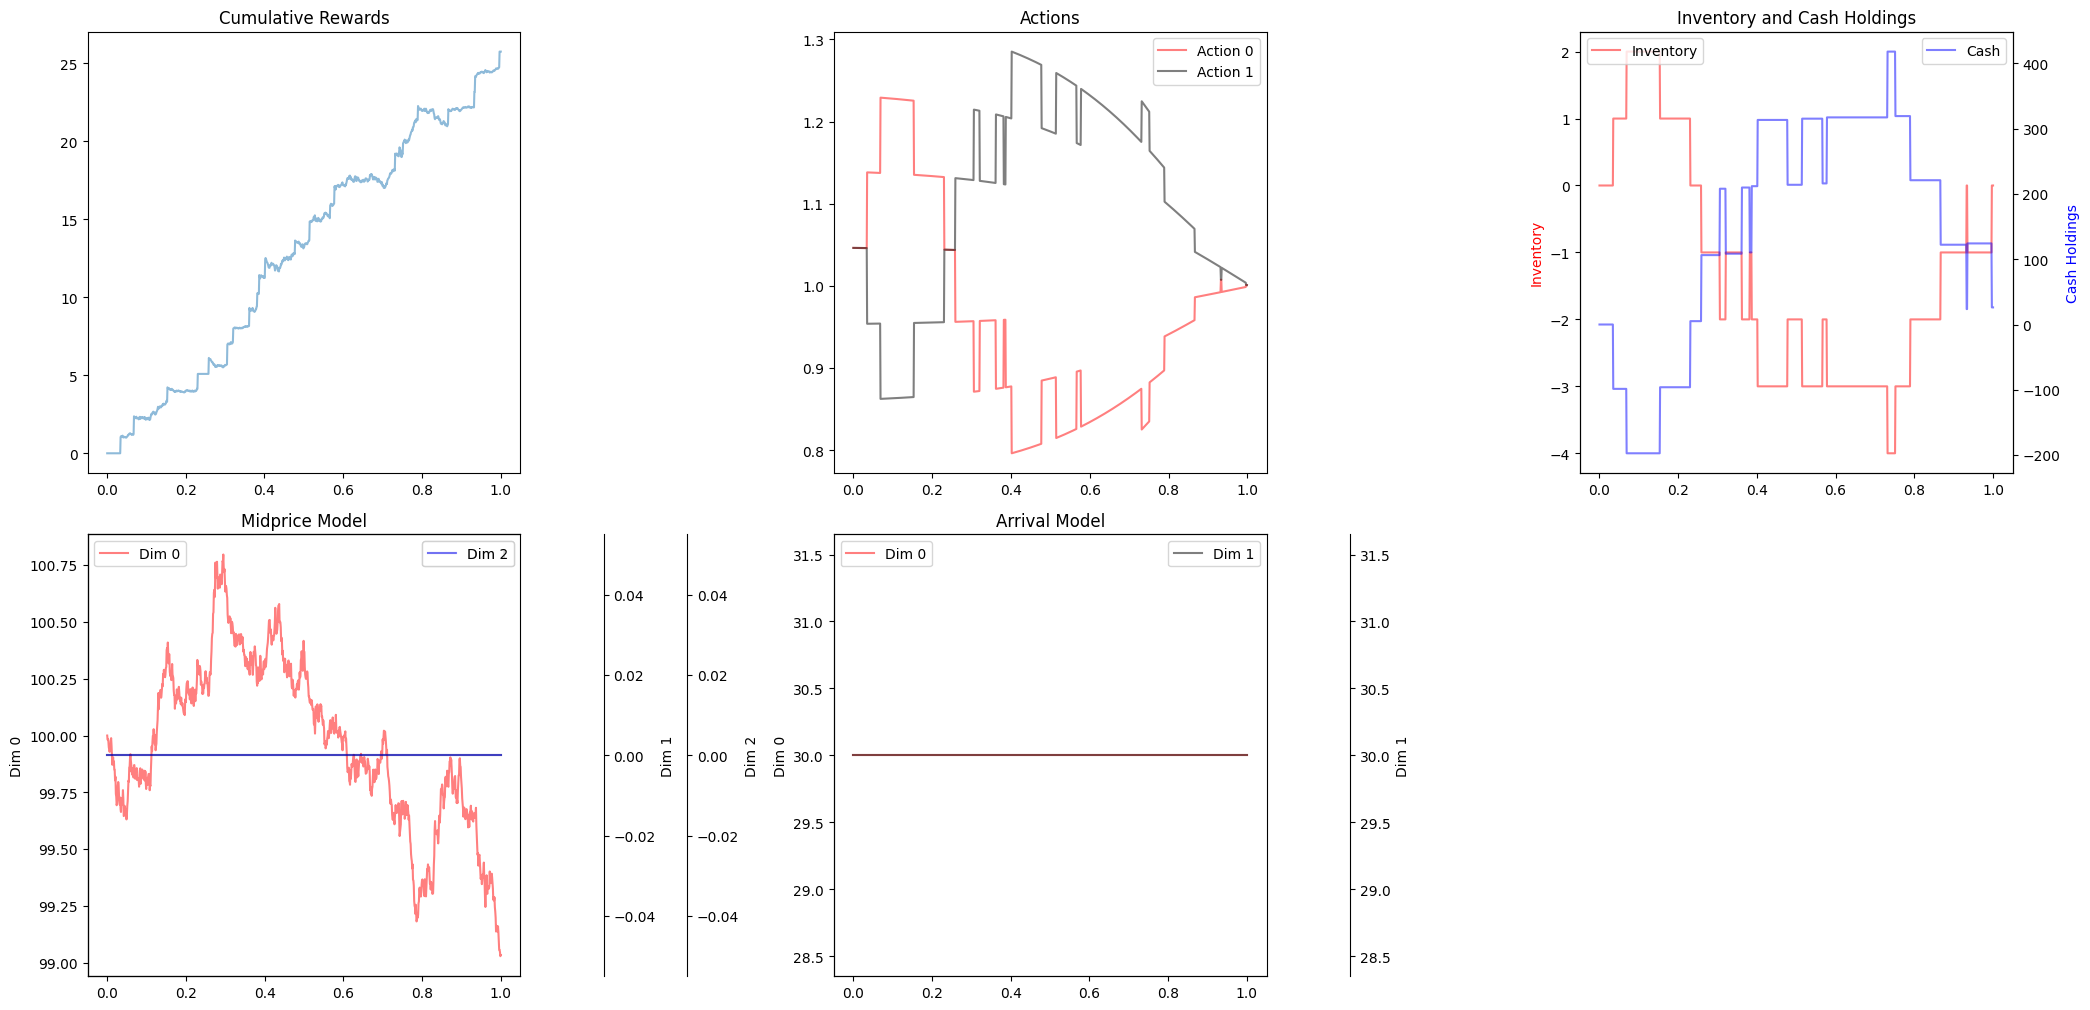

In [58]:
plot_trajectory_extended(as_env, as_agent, seed = 50)

In [59]:
vec_env = get_as_env(num_trajectories)
vec_as = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)


✓ Pre-computed ODE solutions for 1000 time points


In [60]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [61]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [62]:
all_results.append(results)
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065352,21.34272,4.96101,-0.08,3.069462


### Comparison table

In [63]:



# Create the summary table
summary_df = pd.DataFrame({
    'Environment': env_names,
    'Mean PnL': [res['Mean PnL'].values[0] for res in all_results],
    'Std PnL': [res['Std PnL'].values[0] for res in all_results],
    'Mean terminal Inventory': [res['Mean terminal inventory'].values[0] for res in all_results],
    'Std terminal Inventory': [res['Std terminal inventory'].values[0] for res in all_results],
    'Mean Spread': [res['Mean spread'].values[0] for res in all_results]
})

# Display nicely formatted table
display(summary_df.style.format({
    'Mean PnL': '{:.4f}',
    'Std PnL': '{:.4f}',
    'Mean terminal Inventory': '{:.4f}',
    'Std terminal Inventory': '{:.4f}',
    'Mean Spread': '{:.4f}'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center')]},
    {'selector': 'td', 'props': [('text-align', 'center')]}
]))

,Environment,Mean PnL,Std PnL,Mean terminal Inventory,Std terminal Inventory,Mean Spread
0,BM + Poisson + AS,21.1802,4.9008,-0.1060,3.5201,1.9062
1,ABM w/Fads + Poisson + AS,21.3354,4.9569,-0.1060,3.5201,1.9062
2,ABM w/Fads + Modified Poisson + AS,21.3354,4.9569,-0.1060,3.5201,1.9062
3,ABM w/Fads + Modified Poisson + Full Info,21.3427,4.9610,-0.0800,3.0695,2.0654
4,ABM w/Fads + Modified Poisson + Partial Info,21.3427,4.9610,-0.0800,3.0695,2.0654
